# Write gradient descent yourself

CPU companion; no accelerator is required. TPU execution not validated.

- Derive one update before writing the loop
- Read the learning rate through curvature
- Make the trajectory part of the state contract
- Diagnose dynamics instead of only the final number
- Use stopping evidence that survives rescaling

You now have a loss and a gradient. Let’s use them to move a weight toward a better value. We’ll calculate the first two updates ourselves, turn the update into a loop, and try a step size that is too large. Watching the whole path will tell us more than looking only at the final loss.

## The idea

Gradient descent subtracts a scaled gradient from the current parameters. The gradient points toward local increase; its negative gives a local descent direction. A sufficiently large step can cross the useful local region and increase the loss instead.

## The sign tells you which way to step

Take $L(w)=(w-3)^2$, starting from $w=0$. The derivative is $-6$. With learning rate $0.1$, the update gives $w=0.6$, and the loss falls from $9$ to $5.76$. The negative derivative produces a positive parameter change because we subtract it.

With learning rate $1.1$, the first update jumps to $6.6$. The new loss is $12.96$, larger than the starting loss. The derivative was correct in both cases; the step length changed the outcome.

When the loss plot rises, inspect the parameter trajectory and update norm before changing the derivative implementation. Loss hides the side of the minimum on which the parameter lies. A signed trajectory exposes overshoot.

### Pause and reason

Does a correct gradient guarantee that any positive learning rate reduces the loss?

<details><summary>Compare your reasoning</summary>

No. The gradient describes local behavior. Step-size stability depends on the objective's curvature and the update rule; the worked large-step case increases the loss despite the correct derivative.

</details>

## Derive one update before writing the loop

Starting at $w=0$, our gradient is $-4$. Subtracting $0.1$ times $-4$ gives $w=0.4$, whose loss is $2.56$. A second step gives $w=0.72$ and loss $1.6384$. These two hand-computed steps check the sign, learning rate, and whether your history records loss before or after the update.

Define the error $e=w-2$. The next error is $(1-2\eta)e$. This recurrence explains the whole trajectory for this quadratic. An optimizer update must follow the negative gradient; adding it moves away from the minimum. The subscript $k$ counts updates. The symbol $\eta$ is the learning rate, and $e_k=w_k-2$ is the remaining error. Focus on the multiplier $1-2\eta$: its magnitude tells us whether this particular error shrinks.

$$
\begin{aligned}w_{k+1}&=w_k-\eta\,2(w_k-2)\\0&\longrightarrow0.4\longrightarrow0.72\quad(\eta=0.1)\\e_k&=(1-2\eta)^k e_0\end{aligned}
$$

## Read the learning rate through curvature

Rates between $0$ and $0.5$ approach the optimum without crossing it. A rate of $0.5$ reaches it in one ideal step. Rates between $0.5$ and $1$ alternate around the optimum with shrinking error. A rate of $1$ alternates forever; values above $1$ grow in magnitude. These statements follow from the error multiplier for this specific loss.

For $L=a(w-c)^2$ with positive a, the stable interval is $0<\eta<\frac{1}{a}$. Scaling a loss changes the curvature and the safe update scale. There is no universal threshold such as $0.1$ for neural networks.

## Make the trajectory part of the state contract

scan carries the current scalar parameter and stacks one post-update loss per iteration. Its carry must retain a fixed shape and dtype. Our finite step count is a Python integer at construction; if you wrap train in jit, that length must be static or you must choose a different loop formulation.

Keep initial loss separately so you can interpret the first history entry. For this implementation, history$[0]$ is $2.56$, not $4$. A graph without this convention can make two correct training loops look off by one.

## Diagnose dynamics instead of only the final number

Plotting or printing the first few weights and losses reveals a sign error or an overly aggressive step much earlier than waiting for NaN. In this small problem the recurrence is an independent oracle for all tested steps. In larger models use loss, gradient norm, update norm, dtype and finite-value checks.

A deterministic loop should not be “fixed” by changing a random seed. Reproduce the failing rate, derive its error multiplier, lower it according to the model curvature, and check both the trajectory and the endpoint.

## Use stopping evidence that survives rescaling

A small change in the weights does not prove convergence: it can mean the learning rate is tiny. For $L(w)=(w-2)^2$ at $w=0$, the gradient is $-4$. A rate of $10^{-8}$ changes the weight by only $4\times10^{-8}$, while it remains far from the solution. Inspect the objective, gradient magnitude, update magnitude and held-out behavior together. Relative tolerances can help across scales, but no single stopping test certifies a global optimum for a general nonconvex model.

## 1. Prepare the inputs

Create a file named main.py in your activated learning environment. Add these imports and inputs first. Shapes and numeric types are part of the experiment.

In [1]:
# Step 1 — 1. Prepare the inputs: This block establishes the values used by the following steps; run...
# Import jax for this computation.
import jax
import jax.numpy as jnp

This block establishes the values used by the following steps; run the completed file after step $3$.

## 2. Define the computation

Append this block below the inputs. Before proceeding, trace which values are inputs, predictions, and state.

In [2]:
# Step 2 — 2. Define the computation: train defines a state transition that subtracts the derivative.
def loss(w):
    # Return `(w - 2.0) ** 2` to the caller.
    return (w - 2.) ** 2
# Define `train(initial, rate, steps)` to evaluate the objective and its automatic derivatives:
def train(initial, rate, steps):
    # Define `step(w, _)` to evaluate the objective and its automatic derivatives:
    def step(w, _):
        # Differentiate the objective to obtain `next_w` via automatic differentiation.
        next_w = w - rate * jax.grad(loss)(w)
        # Return `(next_w, loss(next_w))` to the caller.
        return next_w, loss(next_w)
    # Return `jax.lax.scan(step, jnp.array(initial), None, length=steps)` to the caller.
    return jax.lax.scan(step, jnp.array(initial), None, length=steps)

train defines a state transition that subtracts the derivative. scan retains the new parameter and records its post-update loss for exactly steps iterations.

## 3. Measure and verify

Append the remaining block, then run python main.py in the terminal. Compare the printed result with the expected output below. Assertions stop execution if the contract fails.

In [3]:
# Step 3 — 3. Measure and verify: The weight approaches 2.0 and the final loss is below 10^{-8}.
final, history = train(0., 0.1, 60)
# Print the observed values to compare against the expected result.
print("Final weight:", float(final))
# Print diagnostic summary of the computed outputs.
print("Final loss:", float(history[-1]))
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(final, 2., atol=1e-4)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert history[-1] < 1e-8
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.all(jnp.diff(history) <= 1e-7)

Final weight: 1.9999969005584717
Final loss: 9.606537787476555e-12


The weight approaches $2.0$ and the final loss is below $10^{-8}$.

## Run the example

In [4]:
# Step 1 — 1. Prepare the inputs: This block establishes the values used by the following steps; run...
# Import jax for this computation.
import jax
import jax.numpy as jnp
# Step 2 — 2. Define the computation: train defines a state transition that subtracts the derivative.
def loss(w):
    # Return `(w - 2.0) ** 2` to the caller.
    return (w - 2.) ** 2
# Define `train(initial, rate, steps)` to evaluate the objective and its automatic derivatives:
def train(initial, rate, steps):
    # Define `step(w, _)` to evaluate the objective and its automatic derivatives:
    def step(w, _):
        # Differentiate the objective to obtain `next_w` via automatic differentiation.
        next_w = w - rate * jax.grad(loss)(w)
        # Return `(next_w, loss(next_w))` to the caller.
        return next_w, loss(next_w)
    # Return `jax.lax.scan(step, jnp.array(initial), None, length=steps)` to the caller.
    return jax.lax.scan(step, jnp.array(initial), None, length=steps)
# Step 3 — 3. Measure and verify: The weight approaches 2.0 and the final loss is below 10^{-8}.
final, history = train(0., 0.1, 60)
# Print the observed values to compare against the expected result.
print("Final weight:", float(final))
# Print diagnostic summary of the computed outputs.
print("Final loss:", float(history[-1]))
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(final, 2., atol=1e-4)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert history[-1] < 1e-8
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.all(jnp.diff(history) <= 1e-7)

Final weight: 1.9999969005584717
Final loss: 9.606537787476555e-12


Expected: The weight approaches $2.0$ and the final loss is below $10^{-8}$.

## Gradient descent trades step size for stability

Predict: Which rate will cause errors to grow rather than shrink?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: Gradient descent trades step size for stability
# Evaluate `rates` from the current inputs and state.
rates = [0.1, 0.5, 1.1]
# Evaluate `series` from the current inputs and state.
series = []
# Loop over `rate_plot` in `rates`:
for rate_plot in rates:
    # Create device-backed JAX array `position_plot`.
    position_plot = jnp.array(0.0)
    # Evaluate `losses` from the current inputs and state.
    losses = []
    # Repeat the update loop over `range(12)` steps:
    for _ in range(12):
        # Append the current step result to `losses`.
        losses.append(float((position_plot - 2) ** 2))
        # Evaluate `position_plot` from the current inputs and state.
        position_plot = position_plot - rate_plot * 2 * (position_plot - 2)
    # Append the current step result to `series`.
    series.append({'label': 'rate ' + str(rate_plot), 'y': losses})
# Evaluate `visual_data` from the current inputs and state.
visual_data = {'kind': 'line', 'x': list(range(12)), 'xlabel': 'completed update', 'ylabel': 'squared error', 'yscale': 'symlog', 'series': series}

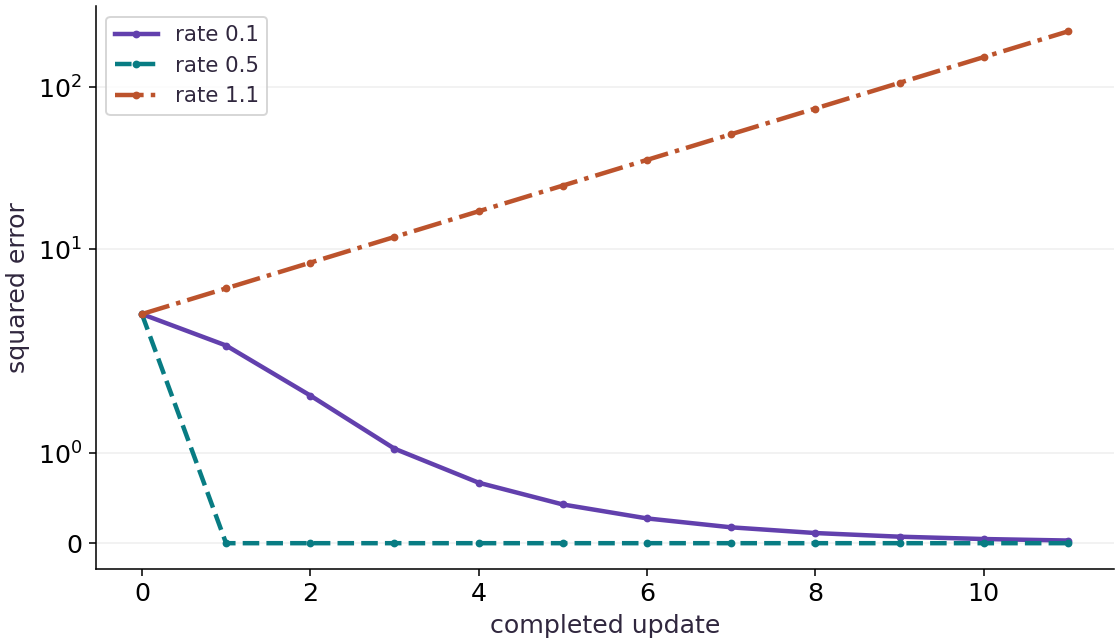

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal axis counts completed updates, including the initial state at $0$. The vertical axis is squared error. It uses a symmetric-log scale: values near zero are on a linear region, while large values are compressed logarithmically. That lets the zero-loss trajectory remain visible.

All three curves begin at loss $4$. Learning rate $0.1$ decreases it gradually; rate $0.5$ reaches zero after one update and stays there. Rate $1.1$ increases it from $4$ to $5.76$, then beyond $200$ by the last plotted update.

### Connect it to the computation

Here the loss is $(w-2)^2$. One update multiplies the weight error $w-2$ by $1-2\eta$. The three rates therefore multiply that error by $0.8$, $0$, and $-1.2$, respectively. Squaring gives loss multipliers $0.64$, $0$, and $1.44$.

The large rate crosses the optimum and lands farther away on each step. The loss plot shows the growing distance, while the sign change follows from the update equation; loss alone does not reveal which side the weight is on. The one-step success of rate $0.5$ depends on this simple quadratic’s curvature and is not a universal best learning rate.

## Check the first two steps

Predict: Does history contain the initial loss or the post-update loss?

In [7]:
# Experiment — Check the first two steps: A hand-derived trajectory checks update sign and the recording...
two_w, two_losses = train(0., 0.1, 2)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(two_w, 0.72)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(two_losses, jnp.array([2.56, 1.6384]))
# Print the observed values to compare against the expected result.
print("First two post-update losses:", two_losses)

First two post-update losses: [2.5600002 1.6384   ]


Expected: $[2.56, 1.6384]$, with final weight $0.72$.

A hand-derived trajectory checks update sign and the recording convention.

## Test the edge of stability

Predict: What does rate $1$ do after five steps from zero?

In [8]:
# Experiment — Test the edge of stability: Magnitude-one error multipliers do not contract even though the...
edge_w, edge_losses = train(0., 1., 5)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(edge_w, 4.)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(edge_losses, jnp.full(5, 4.))

Expected: The weight alternates $0$ and $4$; loss remains $4$.

Magnitude-one error multipliers do not contract even though the loop remains finite.

## A tiny update far from the solution

Predict: Can a parameter-change threshold of $10^{-6}$ declare success while the gradient magnitude is $4$?

In [9]:
# Experiment — A tiny update far from the solution: A stopping rule must distinguish lack of progress from reaching...
# Initialize array `far` with explicit values and shape.
far = jnp.array(0.)
# Evaluate `quadratic` from the current inputs and state.
quadratic = lambda value: (value-2.)**2
# Differentiate the objective to obtain `grad_far` via automatic differentiation.
grad_far = jax.grad(quadratic)(far)
# Evaluate `next_far` from the current inputs and state.
next_far = far - 1e-8*grad_far
# Verify contract: `jnp.abs(next_far - far) < 1e-06`.
assert jnp.abs(next_far-far)<1e-6
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.abs(grad_far)>3.
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert quadratic(next_far)>3.9

Expected: The update is below the threshold, but the objective is still near $4$.

A stopping rule must distinguish lack of progress from reaching a useful solution.

## Your exercise

Run ten steps with learning rate $1.1$. Predict whether the error contracts before executing; show evidence of divergence.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `train(...)` — Call `train` with your updated parameters or inputs from this lesson's workspace.
- `loss(...)` — Call `loss` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Verify contract: `unstable_history[-1] > loss(0.0)`.
2. Verify that the output satisfies the expected shape, finite-value, or numerical contract.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Run ten steps with learning rate 1.1.
unstable, unstable_history = train(...)  # TODO: compute unstable, unstable_history
# Verify contract: `unstable_history[-1] > loss(0.0)`.
assert unstable_history[-1]  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert abs(1 - 2 * 1.1)  # TODO: complete assertion check
```

In [10]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Run ten steps with learning rate 1.1.
# unstable, unstable_history = train(...)  # TODO: compute unstable, unstable_history
# Verify contract: `unstable_history[-1] > loss(0.0)`.
# assert unstable_history[-1]  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert abs(1 - 2 * 1.1)  # TODO: complete assertion check

## Reference solution

Try your own implementation first.

In [11]:
# Exercise solution: Run ten steps with learning rate 1.1.
unstable, unstable_history = train(0., 1.1, 10)
# Verify contract: `unstable_history[-1] > loss(0.0)`.
assert unstable_history[-1] > loss(0.)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert abs(1 - 2 * 1.1) > 1

## Transfer the stability analysis · Transfer / diagnosis

For $4(w-3)^2$, derive a stable rate and verify convergence from zero.

Hint: The error multiplier is $1-8\eta$; use $\eta=0.1$.

### How to write: Transfer the stability analysis — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jax.grad(loss_fn)(params, ...)` — Transforms a scalar-output function into a function returning the gradient PyTree with the same structure as `params`.
- `jax.lax.scan(step_fn, init_carry, xs, length=...)` — Compiles a sequential loop where `step_fn(carry, x)` returns `(next_carry, y)`, returning `(final_carry, stacked_ys)`.

**Step-by-step implementation plan:**
1. Return `4 * (w - 3.0) ** 2` to the caller.
2. Define `scaled_step(w, _)` to evaluate the objective and its automatic derivatives:
3. Differentiate the objective to obtain `new` via automatic differentiation.
4. Return `(new, scaled_loss(new))` to the caller.
5. Run compiled structured control flow via `jax.lax` (`(scaled_w, scaled_history)`).

**Starter code scaffold (fill in the TODOs):**

```python
# Transfer the stability analysis (Transfer / diagnosis): Changing curvature changes the stability interval to...
def scaled_loss(w):
    # Return `4 * (w - 3.0) ** 2` to the caller.
    return ...  # TODO: return computed result
# Define `scaled_step(w, _)` to evaluate the objective and its automatic derivatives:
def scaled_step(w, _):
    # Differentiate the objective to obtain `new` via automatic differentiation.
    new = ...  # TODO: compute new
    # Return `(new, scaled_loss(new))` to the caller.
    return ...  # TODO: return computed result
# Run compiled structured control flow via `jax.lax` (`(scaled_w, scaled_history)`).
scaled_w, scaled_history = jax.lax.scan(...)  # TODO: compute scaled_w, scaled_history
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(scaled_w, 3., atol=1e-5)  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.all(jnp.diff(scaled_history)  # TODO: complete assertion check
```

In [12]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Transfer the stability analysis (Transfer / diagnosis): Changing curvature changes the stability interval to...
# def scaled_loss(w):
    # Return `4 * (w - 3.0) ** 2` to the caller.
#     return ...  # TODO: return computed result
# Define `scaled_step(w, _)` to evaluate the objective and its automatic derivatives:
# def scaled_step(w, _):
    # Differentiate the objective to obtain `new` via automatic differentiation.
#     new = ...  # TODO: compute new
    # Return `(new, scaled_loss(new))` to the caller.
#     return ...  # TODO: return computed result
# Run compiled structured control flow via `jax.lax` (`(scaled_w, scaled_history)`).
# scaled_w, scaled_history = jax.lax.scan(...)  # TODO: compute scaled_w, scaled_history
# Verify that the numerical values match the expected reference within tolerance.
# assert jnp.allclose(scaled_w, 3., atol=1e-5)  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert jnp.all(jnp.diff(scaled_history)  # TODO: complete assertion check

## Reference reasoning

Changing curvature changes the stability interval to $0<\eta<0.25$.

In [13]:
# Transfer the stability analysis (Transfer / diagnosis): Changing curvature changes the stability interval to...
def scaled_loss(w):
    # Return `4 * (w - 3.0) ** 2` to the caller.
    return 4*(w-3.)**2
# Define `scaled_step(w, _)` to evaluate the objective and its automatic derivatives:
def scaled_step(w, _):
    # Differentiate the objective to obtain `new` via automatic differentiation.
    new = w-0.1*jax.grad(scaled_loss)(w)
    # Return `(new, scaled_loss(new))` to the caller.
    return new, scaled_loss(new)
# Run compiled structured control flow via `jax.lax` (`(scaled_w, scaled_history)`).
scaled_w, scaled_history = jax.lax.scan(scaled_step, jnp.array(0.), None, length=20)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(scaled_w, 3., atol=1e-5)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.all(jnp.diff(scaled_history) <= 1e-6)

## Reproduce an uphill update and repair it · Transfer / diagnosis

Show how adding the gradient increases loss, then verify subtraction at the same starting point.

Hint: The derivative at zero is $-4$.

### How to write: Reproduce an uphill update and repair it — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jax.grad(loss_fn)(params, ...)` — Transforms a scalar-output function into a function returning the gradient PyTree with the same structure as `params`.

**Step-by-step implementation plan:**
1. Differentiate the objective to obtain `uphill` via automatic differentiation.
2. Differentiate the objective to obtain `downhill` via automatic differentiation.
3. Verify contract: `loss(uphill) > loss(0.0)`.
4. Verify that the output satisfies the expected shape, finite-value, or numerical contract.
5. Verify that the output satisfies the expected shape, finite-value, or numerical contract.

**Starter code scaffold (fill in the TODOs):**

```python
# Reproduce an uphill update and repair it (Transfer / diagnosis): The sign error is isolated using the same input and rate;...
# Differentiate the objective to obtain `uphill` via automatic differentiation.
uphill = ...  # TODO: compute uphill
# Differentiate the objective to obtain `downhill` via automatic differentiation.
downhill = ...  # TODO: compute downhill
# Verify contract: `loss(uphill) > loss(0.0)`.
assert loss(uphill)  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert loss(downhill)  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(downhill, 0.4)  # TODO: complete assertion check
```

In [14]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Reproduce an uphill update and repair it (Transfer / diagnosis): The sign error is isolated using the same input and rate;...
# Differentiate the objective to obtain `uphill` via automatic differentiation.
# uphill = ...  # TODO: compute uphill
# Differentiate the objective to obtain `downhill` via automatic differentiation.
# downhill = ...  # TODO: compute downhill
# Verify contract: `loss(uphill) > loss(0.0)`.
# assert loss(uphill)  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert loss(downhill)  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert jnp.allclose(downhill, 0.4)  # TODO: complete assertion check

## Reference reasoning

The sign error is isolated using the same input and rate; the repaired first step matches the analytic result.

In [15]:
# Reproduce an uphill update and repair it (Transfer / diagnosis): The sign error is isolated using the same input and rate;...
# Differentiate the objective to obtain `uphill` via automatic differentiation.
uphill = 0. + 0.1*jax.grad(loss)(0.)
# Differentiate the objective to obtain `downhill` via automatic differentiation.
downhill = 0. - 0.1*jax.grad(loss)(0.)
# Verify contract: `loss(uphill) > loss(0.0)`.
assert loss(uphill) > loss(0.)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert loss(downhill) < loss(0.)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(downhill, 0.4)

## Checkpoint

What makes rate $1.1$ unstable for this particular quadratic?

1. The error multiplier has magnitude greater than one
2. scan cannot differentiate scalar weights
3. All learning rates above $0.01$ are unstable

## Diagnose

Record the loss trajectory and parameter values. An alternating, growing error here follows from the update equation; changing the PRNG seed cannot fix it.

## Evidence

Keep the two hand-computed steps, rate stability derivation, edge/divergent runs, scaled-curvature transfer and uphill-update repair. Include the tiny-update counterexample and explain your stopping criteria.

## Carry forward

- A hand-derived trajectory checks update sign and the recording convention.
- Magnitude-one error multipliers do not contract even though the loop remains finite.

## Primary references

- [lax.scan contract](https://docs.jax.dev/en/latest/_autosummary/jax.lax.scan.html)
- [grad API](https://docs.jax.dev/en/latest/_autosummary/jax.grad.html)